In [91]:
import scimap as sm
import numpy as np
import matplotlib.pyplot as plt
import anndata as ad
import pandas as pd
import scanpy as sc
import os
import yaml
from pathlib import Path
from matplotlib import colormaps

In [92]:
preprocessed_dir = Path("/Users/jawadalaaedeen/Desktop/PhD/NMC/preprocessed")
roi_list = [roi for roi in preprocessed_dir.iterdir() if roi.is_dir() and roi.name != '.DS_Store']

In [93]:
#conctenate all the adata files
adata_list = []
for roi in roi_list:
    adata = ad.read_h5ad(roi / "adata.h5ad")
    adata_list.append(adata)
adata = ad.concat(adata_list)

#make obs names unique
adata.obs_names_make_unique()


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning:

Observation names are not unique. To make them unique, call `.obs_names_make_unique`.



In [86]:
long_term = adata[adata.obs['outcome_group'] == 'long_term survival'].obs.exp_name.unique()
short_term = adata[adata.obs['outcome_group'] == 'short_term survival'].obs.exp_name.unique()


['Run141_ROI16', 'Run141_ROI7', 'Run141_ROI23']
Categories (3, object): ['Run141_ROI7', 'Run141_ROI16', 'Run141_ROI23']

In [89]:
adata = sm.tl.foldchange(adata, from_group=short_term, to_group=long_term, imageid="exp_name", phenotype="cell_type")

calculating foldchange
calculating P values


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/scimap/tools/foldchange.py:106: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Run141_ROI16_Run141_ROI7_Run141_ROI23' has dtype incompatible with category, please explicitly cast to a compatible dtype first.

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/scimap/tools/foldchange.py:110: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['Tumor_cells', 'Epithelial_cells', 'Epithelial_cells', 'Epithelial_cells', 'Epithelial_cells', ..., 'Tumor_cells', 'Tumor_cells', 'Tumor_cells', 'Tumor_cells', 'Tumor_cells']
Length: 57296
Categories (18, object): ['Actin+_cells', 'B_cells', 'CD4+_T_cells', 'CD8+_T_cells', ..., 'NK_cells', 'Plasma_cells', 'Treg_T_cells', 'Tumor_cells']' has 

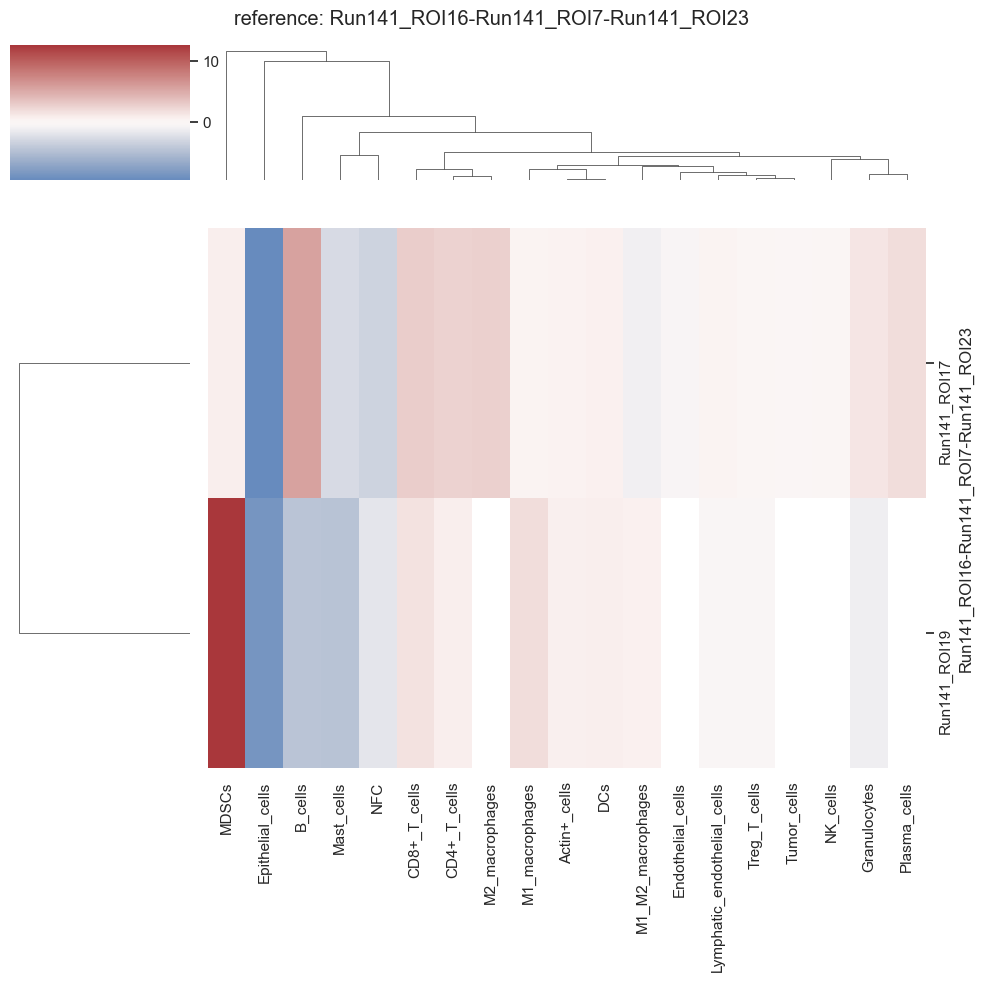

In [90]:
sm.pl.foldchange(adata)

In [77]:
##only outcome group of long_term survival
adata_long = adata[adata.obs['outcome_group'] == 'long_term survival']
adata_short = adata[adata.obs['outcome_group'] == 'short_term survival']

In [38]:
adata_short = sm.tl.spatial_distance(adata_short, x_coordinate='Cell Center X', y_coordinate='Cell Center Y',
                         phenotype='cell_type', imageid="exp_name")

Processing Image: Run141_ROI16
Processing Image: Run141_ROI7
Processing Image: Run141_ROI23


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/scimap/tools/spatial_distance.py:143: ImplicitModificationWarning:

Trying to modify attribute `._uns` of view, initializing view as actual.



In [39]:
adata_long = sm.tl.spatial_distance(adata_long, x_coordinate='Cell Center X', y_coordinate='Cell Center Y',
                         phenotype='cell_type', imageid="exp_name")

Processing Image: Run141_ROI19
Processing Image: Run141_ROI17


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/scimap/tools/spatial_distance.py:143: ImplicitModificationWarning:

Trying to modify attribute `._uns` of view, initializing view as actual.



In [80]:
adata.long = sm.tl.spatial_interaction(adata_long, x_coordinate='Cell Center X', y_coordinate='Cell Center Y', phenotype="cell_type", method = "radius", permutation=30, imageid="exp_name", pval_method='zscore', label='spatial_interaction', verbose=True)

Processing Image: ['Run141_ROI19']
Categories (1, object): ['Run141_ROI19']
Identifying neighbours within 30 pixels of every cell
Mapping phenotype to neighbors
Performing 30 permutations
Consolidating the permutation results
Processing Image: ['Run141_ROI17']
Categories (1, object): ['Run141_ROI17']
Identifying neighbours within 30 pixels of every cell
Mapping phenotype to neighbors
Performing 30 permutations
Consolidating the permutation results


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/scimap/tools/spatial_interaction.py:258: ImplicitModificationWarning:

Trying to modify attribute `._uns` of view, initializing view as actual.



In [30]:
adata = sm.tl.spatial_count(adata, phenotype='cell_type', method='radius', radius=80, label='spatial_count', imageid="exp_name", x_coordinate="Cell Center X", y_coordinate="Cell Center Y")

Identifying neighbours within 80 pixels of every cell
Identifying neighbours within 80 pixels of every cell


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/scimap/tools/spatial_count.py:203: ImplicitModificationWarning:

Trying to modify attribute `._uns` of view, initializing view as actual.



In [ ]:
adata = sm.tl.spatial_cluster(adata, df_name='spatial_count', method='kmeans', k=5, label='neigh_kmeans')

Leiden clustering


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:314: ImplicitModificationWarning:

Setting element `.obsm['X_pca']` of view, initializing view as actual.

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/scipy/sparse/_index.py:145: SparseEfficiencyWarning:

Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/scimap/tools/cluster.py:174: FutureWarning:

In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.



TypeError: object of type 'list_reverseiterator' has no len()

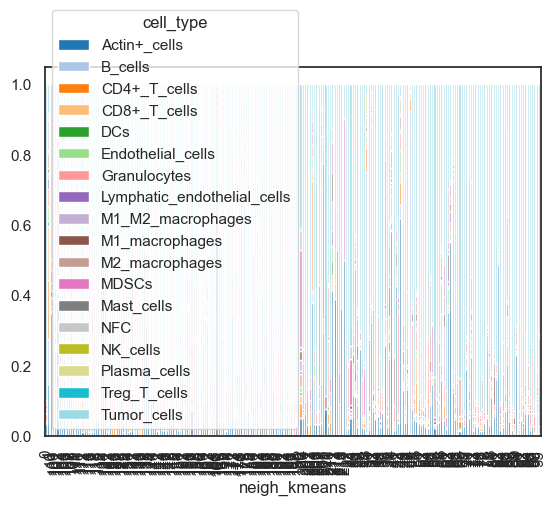

In [35]:
sm.pl.stacked_barplot (adata, x_axis='neigh_kmeans', y_axis='cell_type')